Using device: cuda
TinyPlain-56 params : 853,018
TinyResNet-56 params: 855,770

Huấn luyện TinyPlain-56
Số tham số học được: 853,018
[TinyPlain-56] Epoch 01/20 | LR 0.1000 | Train Loss 2.1667 | Train Acc  17.12% | Test Acc  19.00% | WGrad S1 2.359761e-03 | WGrad S3 3.920048e-04 | AGrad S1 7.131306e-06 | AGrad S3 7.270960e-06 | Time 60.1s
[TinyPlain-56] Epoch 02/20 | LR 0.1000 | Train Loss 2.1886 | Train Acc  18.06% | Test Acc  20.09% | WGrad S1 1.478659e-03 | WGrad S3 2.685327e-04 | AGrad S1 1.325215e-05 | AGrad S3 1.180773e-05 | Time 60.2s
[TinyPlain-56] Epoch 03/20 | LR 0.1000 | Train Loss 2.1347 | Train Acc  19.59% | Test Acc  18.49% | WGrad S1 1.490981e-03 | WGrad S3 3.231406e-04 | AGrad S1 1.204482e-05 | AGrad S3 1.355113e-05 | Time 60.4s
[TinyPlain-56] Epoch 04/20 | LR 0.1000 | Train Loss 1.9538 | Train Acc  25.81% | Test Acc  26.46% | WGrad S1 2.103078e-03 | WGrad S3 4.156345e-04 | AGrad S1 1.685554e-05 | AGrad S3 1.508353e-05 | Time 60.5s
[TinyPlain-56] Epoch 05/20 | LR 0.1000 

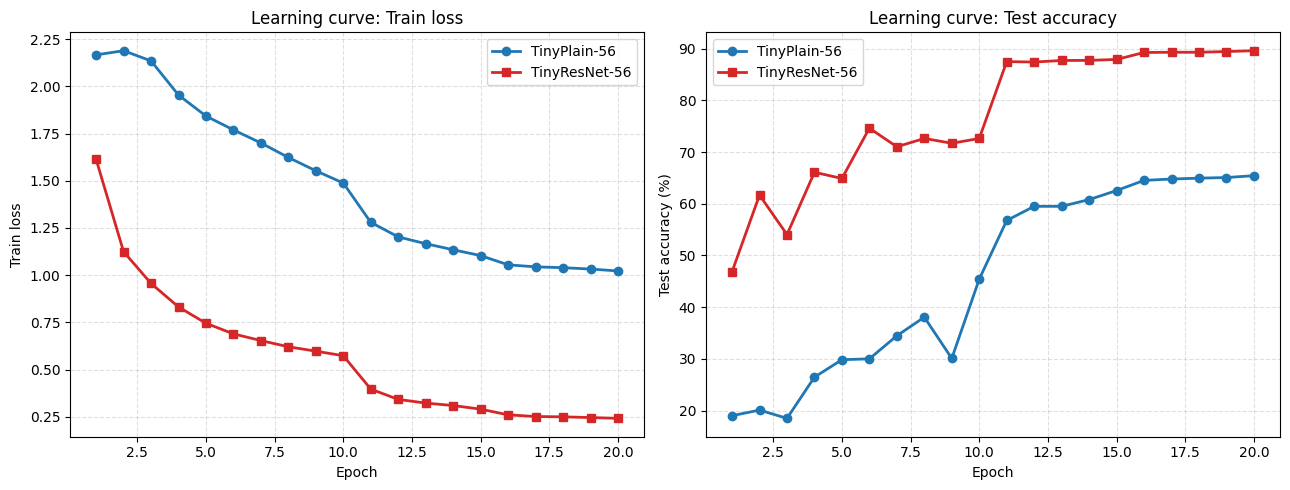

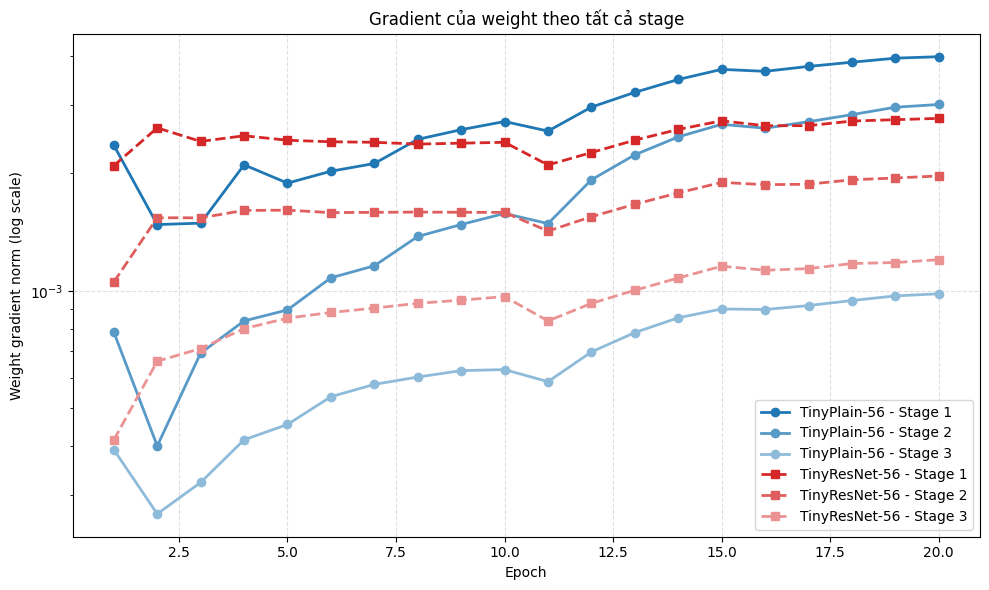

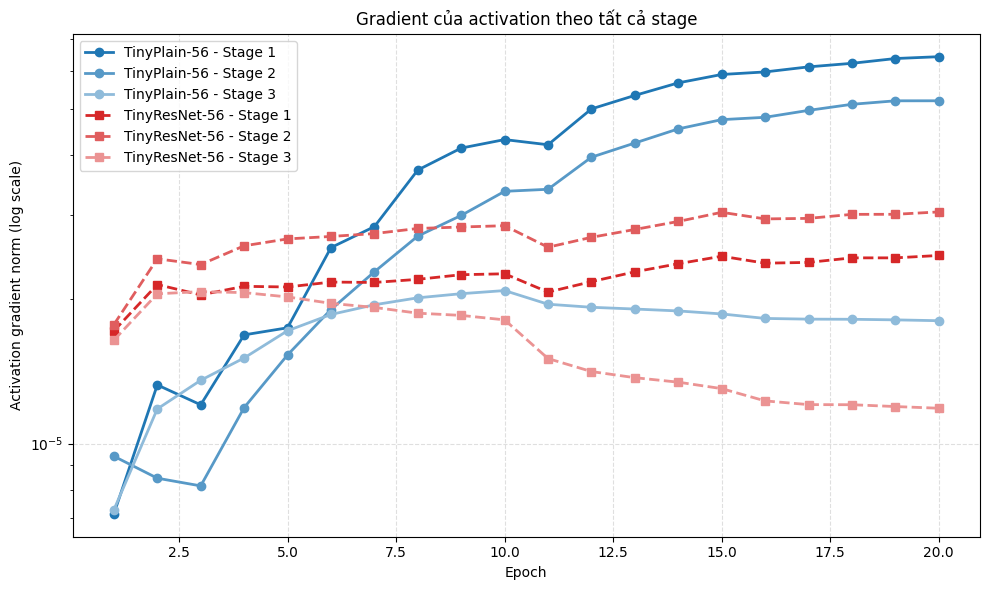

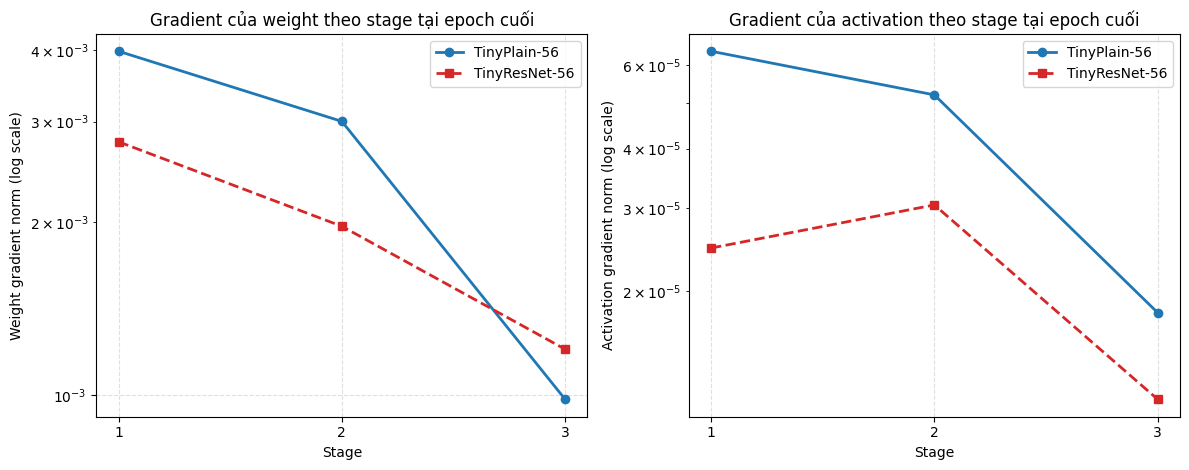


TÓM TẮT KẾT QUẢ
TinyPlain-56  - Best test accuracy : 65.43%
TinyResNet-56 - Best test accuracy : 89.60%

Gradient ở epoch cuối:
TinyPlain-56
  Weight     : S1=3.979229e-03, S2=3.002035e-03, S3=9.830084e-04
  Activation : S1=6.417471e-05, S2=5.192020e-05, S3=1.804306e-05
TinyResNet-56
  Weight     : S1=2.765951e-03, S2=1.969756e-03, S3=1.201948e-03
  Activation : S1=2.468843e-05, S2=3.043549e-05, S3=1.184762e-05

Gợi ý diễn giải:
- Nếu gradient của activation suy giảm rõ khi đi từ stage nông sang stage sâu trong TinyPlain-56,
  nhưng được duy trì đồng đều hơn trong TinyResNet-56, thì đó là dấu hiệu trực quan cho thấy
  residual shortcut hỗ trợ quá trình lan truyền gradient.

- Nếu TinyResNet-56 có train loss giảm nhanh hơn và test accuracy cao hơn,
  có thể kết luận rằng skip connection không chỉ cải thiện dòng gradient
  mà còn giúp bài toán tối ưu mạng sâu trở nên dễ hơn.

- Weight gradient phản ánh mức cập nhật của tham số,
  còn activation gradient phản ánh trực tiếp hơn tín hiệu g

In [ ]:
# ============================================================
# GIÁO TRÌNH: THỊ GIÁC MÁY: TỪ XỬ LÝ ẢNH ĐẾN HỌC SÂU
# BÀI CODE MINH HỌA: TRỰC QUAN HÓA VANISHING / EXPLODING GRADIENT
# Chương/Mục liên quan: Chương 7 - Huấn luyện mạng học sâu trong thị giác máy
# ============================================================

# ============================================================
# MÔ TẢ
# ============================================================

# Mục đích:
# - Minh họa hiện tượng vanishing / exploding gradient trong mạng CNN sâu.
# - So sánh TinyPlain-56 và TinyResNet-56 trên CIFAR-10.
# - Quan sát vai trò của residual shortcut trong việc duy trì dòng gradient.

# Sau khi chạy code, người học cần:
# 1. Quan sát được learning curve của hai mô hình.
# 2. So sánh được gradient của weight và activation theo từng stage.
# 3. Hiểu vì sao skip connection giúp quá trình tối ưu mạng sâu ổn định hơn.

# Input:
# - Dataset CIFAR-10 từ torchvision.datasets.
# - Kiểu dữ liệu: ảnh màu RGB kích thước 32 x 32 x 3.

# Output:
# - Learning curve: train loss và test accuracy.
# - Đồ thị gradient của weight theo epoch.
# - Đồ thị gradient của activation theo epoch.
# - Đồ thị gradient theo stage tại epoch cuối.
# - Bảng tóm tắt best test accuracy và gradient cuối cùng.

# Lưu ý:
# Đoạn code này được xây dựng với sự hỗ trợ của công cụ AI.
# Giảng viên đã đọc, kiểm tra và hiệu chỉnh nhằm bảo đảm tính chính xác,
# tính sư phạm và sự phù hợp với nội dung lý thuyết trong giáo trình.

# ============================================================
# 1. CÀI ĐẶT VÀ IMPORT THƯ VIỆN
# ============================================================

import os
import copy
import math
import time
import random
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors as mcolors

import torch
import torch.nn as nn
import torch.optim as optim
import torch.backends.cudnn as cudnn
import torch.nn.functional as F

from torch.utils.data import DataLoader
from torchvision import datasets, transforms


# ============================================================
# 2. THIẾT LẬP DETERMINISTIC
# ============================================================

GLOBAL_SEED = 42

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(GLOBAL_SEED)

cudnn.benchmark = False
cudnn.deterministic = True

try:
    torch.use_deterministic_algorithms(True)
except Exception as e:
    print("Không bật được torch.use_deterministic_algorithms(True):", e)

os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)


# ============================================================
# 3. CẤU HÌNH THÍ NGHIỆM
# ============================================================

BATCH_SIZE = 128
NUM_EPOCHS = 20
LEARNING_RATE = 0.1
MOMENTUM = 0.9
WEIGHT_DECAY = 5e-4

CHANNELS = (16, 32, 64)
BLOCKS_PER_STAGE = (9, 9, 9)

CIFAR10_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR10_STD  = (0.2023, 0.1994, 0.2010)


# ============================================================
# 4. HÀM HỖ TRỢ MÀU SẮC
# ============================================================

def lighten_color(color, amount=0.5):
    c = np.array(mcolors.to_rgb(color))
    white = np.array([1.0, 1.0, 1.0])
    out = c + (white - c) * amount
    return tuple(np.clip(out, 0, 1))

PLAIN_BASE = "#1f77b4"
RES_BASE   = "#d62728"

PLAIN_S1 = lighten_color(PLAIN_BASE, 0.00)
PLAIN_S2 = lighten_color(PLAIN_BASE, 0.25)
PLAIN_S3 = lighten_color(PLAIN_BASE, 0.50)

RES_S1 = lighten_color(RES_BASE, 0.00)
RES_S2 = lighten_color(RES_BASE, 0.25)
RES_S3 = lighten_color(RES_BASE, 0.50)


# ============================================================
# 5. TẢI DỮ LIỆU ĐẦU VÀO
# ============================================================

base_train_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
])

train_dataset = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=base_train_transform
)

test_dataset = datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=test_transform
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)


# ============================================================
# 6. TIỀN XỬ LÝ VÀ AUGMENTATION DETERMINISTIC
# ============================================================

def deterministic_random_crop_and_flip(img, epoch, sample_index, padding=4):
    seed = GLOBAL_SEED + epoch * 100000 + sample_index
    rng = random.Random(seed)

    img_pad = F.pad(img, (padding, padding, padding, padding), mode="reflect")

    _, h_pad, w_pad = img_pad.shape
    crop_size = 32

    max_top = h_pad - crop_size
    max_left = w_pad - crop_size

    top = rng.randint(0, max_top)
    left = rng.randint(0, max_left)

    img_crop = img_pad[:, top:top + crop_size, left:left + crop_size]

    if rng.random() < 0.5:
        img_crop = torch.flip(img_crop, dims=[2])

    return img_crop


# ============================================================
# 7. SINH MINIBATCH CỐ ĐỊNH CHO TỪNG EPOCH
# ============================================================

def build_epoch_minibatches(num_samples, batch_size, num_epochs, seed=42):
    epoch_minibatches = []
    base_rng = np.random.RandomState(seed)

    for _ in range(num_epochs):
        perm_seed = int(base_rng.randint(0, 2**31 - 1))
        epoch_rng = np.random.RandomState(perm_seed)
        perm = epoch_rng.permutation(num_samples).tolist()

        minibatches = [
            perm[i:i + batch_size]
            for i in range(0, num_samples, batch_size)
        ]
        epoch_minibatches.append(minibatches)

    return epoch_minibatches

epoch_minibatches = build_epoch_minibatches(
    num_samples=len(train_dataset),
    batch_size=BATCH_SIZE,
    num_epochs=NUM_EPOCHS,
    seed=GLOBAL_SEED
)

def make_batch_from_indices(dataset, indices, epoch):
    images = []
    targets = []

    for idx in indices:
        img, target = dataset[idx]
        img = deterministic_random_crop_and_flip(img, epoch=epoch, sample_index=idx)
        images.append(img)
        targets.append(target)

    images = torch.stack(images, dim=0)
    targets = torch.tensor(targets, dtype=torch.long)
    return images, targets


# ============================================================
# 8. CÁC HÀM KIỂM TRA VÀ ĐÁNH GIÁ
# ============================================================

def count_trainable_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def compute_stage_grad_norm(module):
    # Công thức minh họa:
    # Gradient RMS = sqrt(sum(g^2) / N)

    sq_sum = 0.0
    numel = 0

    for p in module.parameters():
        if p.grad is not None:
            g = p.grad.detach()
            sq_sum += torch.sum(g * g).item()
            numel += g.numel()

    if numel == 0:
        return 0.0

    return math.sqrt(sq_sum / numel)

def compute_activation_grad_norm(tensor):
    # Công thức minh họa:
    # Activation gradient RMS = sqrt(mean(g^2))

    if tensor is None:
        return 0.0
    if tensor.grad is None:
        return 0.0

    g = tensor.grad.detach()
    return torch.sqrt(torch.mean(g * g)).item()

def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    with torch.no_grad():
        for images, targets in loader:
            images = images.to(DEVICE, non_blocking=True)
            targets = targets.to(DEVICE, non_blocking=True)

            logits = model(images)
            loss = criterion(logits, targets)

            total_loss += loss.item() * images.size(0)
            total_correct += (logits.argmax(dim=1) == targets).sum().item()
            total_samples += images.size(0)

    avg_loss = total_loss / total_samples
    avg_acc = total_correct / total_samples
    return avg_loss, avg_acc


# ============================================================
# 9. XÂY DỰNG CÁC BLOCK CƠ SỞ
# ============================================================

class PlainBlock(nn.Module):
    # Conv3x3 -> BN -> ReLU -> Conv3x3 -> BN -> ReLU
    # Không có skip connection

    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()

        self.conv1 = nn.Conv2d(
            in_channels, out_channels, kernel_size=3,
            stride=stride, padding=1, bias=False
        )
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu1 = nn.ReLU(inplace=True)

        self.conv2 = nn.Conv2d(
            out_channels, out_channels, kernel_size=3,
            stride=1, padding=1, bias=False
        )
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.relu2 = nn.ReLU(inplace=True)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu1(x)

        x = self.conv2(x)
        x = self.bn2(x)
        x = self.relu2(x)
        return x


class ResidualBlock(nn.Module):
    # Công thức minh họa:
    # y = F(x) + x
    # Đây là dòng code tương ứng trong forward:
    # out = out + identity

    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()

        self.conv1 = nn.Conv2d(
            in_channels, out_channels, kernel_size=3,
            stride=stride, padding=1, bias=False
        )
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

        self.conv2 = nn.Conv2d(
            out_channels, out_channels, kernel_size=3,
            stride=1, padding=1, bias=False
        )
        self.bn2 = nn.BatchNorm2d(out_channels)

        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(
                    in_channels, out_channels,
                    kernel_size=1, stride=stride, bias=False
                ),
                nn.BatchNorm2d(out_channels)
            )
        else:
            self.shortcut = nn.Identity()

    def forward(self, x):
        identity = self.shortcut(x)

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        out = out + identity
        out = self.relu(out)
        return out


# ============================================================
# 10. XÂY DỰNG TINYPLAIN-56 VÀ TINYRESNET-56
# ============================================================

class TinyPlain56(nn.Module):
    def __init__(self, num_classes=10, channels=(16, 32, 64), blocks_per_stage=(9, 9, 9)):
        super().__init__()

        c1, c2, c3 = channels
        b1, b2, b3 = blocks_per_stage

        self.stem = nn.Sequential(
            nn.Conv2d(3, c1, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(c1),
            nn.ReLU(inplace=True)
        )

        self.stage1 = self._make_stage(PlainBlock, c1, c1, b1, stride=1)
        self.stage2 = self._make_stage(PlainBlock, c1, c2, b2, stride=2)
        self.stage3 = self._make_stage(PlainBlock, c2, c3, b3, stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(c3, num_classes)

        self._init_weights()

        self.feat_s1 = None
        self.feat_s2 = None
        self.feat_s3 = None

    def _make_stage(self, block, in_channels, out_channels, num_blocks, stride):
        blocks = [block(in_channels, out_channels, stride=stride)]
        for _ in range(1, num_blocks):
            blocks.append(block(out_channels, out_channels, stride=1))
        return nn.Sequential(*blocks)

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")
            elif isinstance(m, (nn.BatchNorm2d, nn.GroupNorm)):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.stem(x)

        x = self.stage1(x)
        if x.requires_grad:
            x.retain_grad()
            self.feat_s1 = x
        else:
            self.feat_s1 = None

        x = self.stage2(x)
        if x.requires_grad:
            x.retain_grad()
            self.feat_s2 = x
        else:
            self.feat_s2 = None

        x = self.stage3(x)
        if x.requires_grad:
            x.retain_grad()
            self.feat_s3 = x
        else:
            self.feat_s3 = None

        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x


class TinyResNet56(nn.Module):
    def __init__(self, num_classes=10, channels=(16, 32, 64), blocks_per_stage=(9, 9, 9)):
        super().__init__()

        c1, c2, c3 = channels
        b1, b2, b3 = blocks_per_stage

        self.stem = nn.Sequential(
            nn.Conv2d(3, c1, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(c1),
            nn.ReLU(inplace=True)
        )

        self.stage1 = self._make_stage(ResidualBlock, c1, c1, b1, stride=1)
        self.stage2 = self._make_stage(ResidualBlock, c1, c2, b2, stride=2)
        self.stage3 = self._make_stage(ResidualBlock, c2, c3, b3, stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(c3, num_classes)

        self._init_weights()

        self.feat_s1 = None
        self.feat_s2 = None
        self.feat_s3 = None

    def _make_stage(self, block, in_channels, out_channels, num_blocks, stride):
        blocks = [block(in_channels, out_channels, stride=stride)]
        for _ in range(1, num_blocks):
            blocks.append(block(out_channels, out_channels, stride=1))
        return nn.Sequential(*blocks)

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")
            elif isinstance(m, (nn.BatchNorm2d, nn.GroupNorm)):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01)
                nn.init.zeros_(m.bias)

        for m in self.modules():
            if isinstance(m, ResidualBlock):
                nn.init.zeros_(m.bn2.weight)

    def forward(self, x):
        x = self.stem(x)

        x = self.stage1(x)
        if x.requires_grad:
            x.retain_grad()
            self.feat_s1 = x
        else:
            self.feat_s1 = None

        x = self.stage2(x)
        if x.requires_grad:
            x.retain_grad()
            self.feat_s2 = x
        else:
            self.feat_s2 = None

        x = self.stage3(x)
        if x.requires_grad:
            x.retain_grad()
            self.feat_s3 = x
        else:
            self.feat_s3 = None

        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x


# ============================================================
# 11. HUẤN LUYỆN MÔ HÌNH
# ============================================================

def train_model_with_fixed_minibatches(model, model_name, train_dataset, test_loader, epoch_minibatches, num_epochs=20):
    model = model.to(DEVICE)
    criterion = nn.CrossEntropyLoss()

    optimizer = optim.SGD(
        model.parameters(),
        lr=LEARNING_RATE,
        momentum=MOMENTUM,
        weight_decay=WEIGHT_DECAY
    )

    scheduler = optim.lr_scheduler.MultiStepLR(
        optimizer,
        milestones=[int(num_epochs * 0.5), int(num_epochs * 0.75)],
        gamma=0.1
    )

    history = {
        "train_loss": [],
        "train_acc": [],
        "test_loss": [],
        "test_acc": [],
        "lr": [],

        "grad_w_s1": [],
        "grad_w_s2": [],
        "grad_w_s3": [],

        "grad_a_s1": [],
        "grad_a_s2": [],
        "grad_a_s3": [],
    }

    best_acc = 0.0
    best_state = None

    print(f"\n{'='*72}")
    print(f"Huấn luyện {model_name}")
    print(f"Số tham số học được: {count_trainable_params(model):,}")
    print(f"{'='*72}")

    for epoch in range(num_epochs):
        model.train()
        epoch_start = time.time()

        running_loss = 0.0
        running_correct = 0
        running_samples = 0

        grad_w_s1_batches = []
        grad_w_s2_batches = []
        grad_w_s3_batches = []

        grad_a_s1_batches = []
        grad_a_s2_batches = []
        grad_a_s3_batches = []

        for batch_indices in epoch_minibatches[epoch]:
            images, targets = make_batch_from_indices(train_dataset, batch_indices, epoch=epoch)
            images = images.to(DEVICE, non_blocking=True)
            targets = targets.to(DEVICE, non_blocking=True)

            optimizer.zero_grad()

            logits = model(images)
            loss = criterion(logits, targets)
            loss.backward()

            gw1 = compute_stage_grad_norm(model.stage1)
            gw2 = compute_stage_grad_norm(model.stage2)
            gw3 = compute_stage_grad_norm(model.stage3)

            ga1 = compute_activation_grad_norm(model.feat_s1)
            ga2 = compute_activation_grad_norm(model.feat_s2)
            ga3 = compute_activation_grad_norm(model.feat_s3)

            grad_w_s1_batches.append(gw1)
            grad_w_s2_batches.append(gw2)
            grad_w_s3_batches.append(gw3)

            grad_a_s1_batches.append(ga1)
            grad_a_s2_batches.append(ga2)
            grad_a_s3_batches.append(ga3)

            optimizer.step()

            running_loss += loss.item() * images.size(0)
            running_correct += (logits.argmax(dim=1) == targets).sum().item()
            running_samples += images.size(0)

        scheduler.step()

        train_loss = running_loss / running_samples
        train_acc = running_correct / running_samples
        test_loss, test_acc = evaluate(model, test_loader, criterion)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["test_loss"].append(test_loss)
        history["test_acc"].append(test_acc)
        history["lr"].append(optimizer.param_groups[0]["lr"])

        history["grad_w_s1"].append(float(np.mean(grad_w_s1_batches)))
        history["grad_w_s2"].append(float(np.mean(grad_w_s2_batches)))
        history["grad_w_s3"].append(float(np.mean(grad_w_s3_batches)))

        history["grad_a_s1"].append(float(np.mean(grad_a_s1_batches)))
        history["grad_a_s2"].append(float(np.mean(grad_a_s2_batches)))
        history["grad_a_s3"].append(float(np.mean(grad_a_s3_batches)))

        if test_acc > best_acc:
            best_acc = test_acc
            best_state = copy.deepcopy(model.state_dict())

        epoch_time = time.time() - epoch_start

        print(
            f"[{model_name}] Epoch {epoch+1:02d}/{num_epochs:02d} | "
            f"LR {optimizer.param_groups[0]['lr']:.4f} | "
            f"Train Loss {train_loss:.4f} | Train Acc {train_acc*100:6.2f}% | "
            f"Test Acc {test_acc*100:6.2f}% | "
            f"WGrad S1 {history['grad_w_s1'][-1]:.6e} | "
            f"WGrad S3 {history['grad_w_s3'][-1]:.6e} | "
            f"AGrad S1 {history['grad_a_s1'][-1]:.6e} | "
            f"AGrad S3 {history['grad_a_s3'][-1]:.6e} | "
            f"Time {epoch_time:.1f}s"
        )

    if best_state is not None:
        model.load_state_dict(best_state)

    history["best_test_acc"] = best_acc
    return model, history


# ============================================================
# 12. KHỞI TẠO HAI MẠNG
# ============================================================

set_seed(GLOBAL_SEED)

tiny_plain_56 = TinyPlain56(
    num_classes=10,
    channels=CHANNELS,
    blocks_per_stage=BLOCKS_PER_STAGE
)

set_seed(GLOBAL_SEED)

tiny_resnet_56 = TinyResNet56(
    num_classes=10,
    channels=CHANNELS,
    blocks_per_stage=BLOCKS_PER_STAGE
)

print("TinyPlain-56 params :", f"{count_trainable_params(tiny_plain_56):,}")
print("TinyResNet-56 params:", f"{count_trainable_params(tiny_resnet_56):,}")


# ============================================================
# 13. XỬ LÝ CHÍNH: HUẤN LUYỆN HAI MÔ HÌNH
# ============================================================

tiny_plain_56, hist_plain = train_model_with_fixed_minibatches(
    tiny_plain_56,
    "TinyPlain-56",
    train_dataset,
    test_loader,
    epoch_minibatches,
    num_epochs=NUM_EPOCHS
)

tiny_resnet_56, hist_resnet = train_model_with_fixed_minibatches(
    tiny_resnet_56,
    "TinyResNet-56",
    train_dataset,
    test_loader,
    epoch_minibatches,
    num_epochs=NUM_EPOCHS
)


# ============================================================
# 14. HIỂN THỊ KẾT QUẢ: LEARNING CURVE
# ============================================================

epochs = np.arange(1, NUM_EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(
    epochs, hist_plain["train_loss"],
    marker='o', linewidth=2, color=PLAIN_S1, label="TinyPlain-56"
)
axes[0].plot(
    epochs, hist_resnet["train_loss"],
    marker='s', linewidth=2, color=RES_S1, label="TinyResNet-56"
)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Train loss")
axes[0].set_title("Learning curve: Train loss")
axes[0].grid(True, linestyle='--', alpha=0.4)
axes[0].legend()

axes[1].plot(
    epochs, np.array(hist_plain["test_acc"]) * 100,
    marker='o', linewidth=2, color=PLAIN_S1, label="TinyPlain-56"
)
axes[1].plot(
    epochs, np.array(hist_resnet["test_acc"]) * 100,
    marker='s', linewidth=2, color=RES_S1, label="TinyResNet-56"
)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Test accuracy (%)")
axes[1].set_title("Learning curve: Test accuracy")
axes[1].grid(True, linestyle='--', alpha=0.4)
axes[1].legend()

plt.tight_layout()
plt.show()


# ============================================================
# 15. HIỂN THỊ KẾT QUẢ: GRADIENT CỦA WEIGHT THEO EPOCH
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    epochs, hist_plain["grad_w_s1"],
    marker='o', linewidth=2, color=PLAIN_S1, label="TinyPlain-56 - Stage 1"
)
plt.plot(
    epochs, hist_plain["grad_w_s2"],
    marker='o', linewidth=2, color=PLAIN_S2, label="TinyPlain-56 - Stage 2"
)
plt.plot(
    epochs, hist_plain["grad_w_s3"],
    marker='o', linewidth=2, color=PLAIN_S3, label="TinyPlain-56 - Stage 3"
)

plt.plot(
    epochs, hist_resnet["grad_w_s1"],
    marker='s', linewidth=2, linestyle='--', color=RES_S1, label="TinyResNet-56 - Stage 1"
)
plt.plot(
    epochs, hist_resnet["grad_w_s2"],
    marker='s', linewidth=2, linestyle='--', color=RES_S2, label="TinyResNet-56 - Stage 2"
)
plt.plot(
    epochs, hist_resnet["grad_w_s3"],
    marker='s', linewidth=2, linestyle='--', color=RES_S3, label="TinyResNet-56 - Stage 3"
)

plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("Weight gradient norm, log scale")
plt.title("Gradient của weight theo tất cả stage")
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()


# ============================================================
# 16. HIỂN THỊ KẾT QUẢ: GRADIENT CỦA ACTIVATION THEO EPOCH
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    epochs, hist_plain["grad_a_s1"],
    marker='o', linewidth=2, color=PLAIN_S1, label="TinyPlain-56 - Stage 1"
)
plt.plot(
    epochs, hist_plain["grad_a_s2"],
    marker='o', linewidth=2, color=PLAIN_S2, label="TinyPlain-56 - Stage 2"
)
plt.plot(
    epochs, hist_plain["grad_a_s3"],
    marker='o', linewidth=2, color=PLAIN_S3, label="TinyPlain-56 - Stage 3"
)

plt.plot(
    epochs, hist_resnet["grad_a_s1"],
    marker='s', linewidth=2, linestyle='--', color=RES_S1, label="TinyResNet-56 - Stage 1"
)
plt.plot(
    epochs, hist_resnet["grad_a_s2"],
    marker='s', linewidth=2, linestyle='--', color=RES_S2, label="TinyResNet-56 - Stage 2"
)
plt.plot(
    epochs, hist_resnet["grad_a_s3"],
    marker='s', linewidth=2, linestyle='--', color=RES_S3, label="TinyResNet-56 - Stage 3"
)

plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("Activation gradient norm, log scale")
plt.title("Gradient của activation theo tất cả stage")
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()


# ============================================================
# 17. HIỂN THỊ KẾT QUẢ: GRADIENT THEO STAGE TẠI EPOCH CUỐI
# ============================================================

stage_ids = np.array([1, 2, 3])

plain_weight_last = [
    hist_plain["grad_w_s1"][-1],
    hist_plain["grad_w_s2"][-1],
    hist_plain["grad_w_s3"][-1],
]

res_weight_last = [
    hist_resnet["grad_w_s1"][-1],
    hist_resnet["grad_w_s2"][-1],
    hist_resnet["grad_w_s3"][-1],
]

plain_act_last = [
    hist_plain["grad_a_s1"][-1],
    hist_plain["grad_a_s2"][-1],
    hist_plain["grad_a_s3"][-1],
]

res_act_last = [
    hist_resnet["grad_a_s1"][-1],
    hist_resnet["grad_a_s2"][-1],
    hist_resnet["grad_a_s3"][-1],
]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

axes[0].plot(stage_ids, plain_weight_last, marker='o', linewidth=2, color=PLAIN_S1, label="TinyPlain-56")
axes[0].plot(stage_ids, res_weight_last, marker='s', linewidth=2, linestyle='--', color=RES_S1, label="TinyResNet-56")
axes[0].set_yscale("log")
axes[0].set_xticks(stage_ids)
axes[0].set_xlabel("Stage")
axes[0].set_ylabel("Weight gradient norm, log scale")
axes[0].set_title("Gradient của weight theo stage tại epoch cuối")
axes[0].grid(True, linestyle='--', alpha=0.4)
axes[0].legend()

axes[1].plot(stage_ids, plain_act_last, marker='o', linewidth=2, color=PLAIN_S1, label="TinyPlain-56")
axes[1].plot(stage_ids, res_act_last, marker='s', linewidth=2, linestyle='--', color=RES_S1, label="TinyResNet-56")
axes[1].set_yscale("log")
axes[1].set_xticks(stage_ids)
axes[1].set_xlabel("Stage")
axes[1].set_ylabel("Activation gradient norm, log scale")
axes[1].set_title("Gradient của activation theo stage tại epoch cuối")
axes[1].grid(True, linestyle='--', alpha=0.4)
axes[1].legend()

plt.tight_layout()
plt.show()


# ============================================================
# 18. KIỂM TRA KẾT QUẢ
# ============================================================

print("\n" + "="*72)
print("TÓM TẮT KẾT QUẢ")
print("="*72)

print(f"TinyPlain-56  - Best test accuracy : {hist_plain['best_test_acc']*100:.2f}%")
print(f"TinyResNet-56 - Best test accuracy : {hist_resnet['best_test_acc']*100:.2f}%")

print("\nGradient ở epoch cuối:")

print("TinyPlain-56")
print(f"  Weight     : S1={hist_plain['grad_w_s1'][-1]:.6e}, S2={hist_plain['grad_w_s2'][-1]:.6e}, S3={hist_plain['grad_w_s3'][-1]:.6e}")
print(f"  Activation : S1={hist_plain['grad_a_s1'][-1]:.6e}, S2={hist_plain['grad_a_s2'][-1]:.6e}, S3={hist_plain['grad_a_s3'][-1]:.6e}")

print("TinyResNet-56")
print(f"  Weight     : S1={hist_resnet['grad_w_s1'][-1]:.6e}, S2={hist_resnet['grad_w_s2'][-1]:.6e}, S3={hist_resnet['grad_w_s3'][-1]:.6e}")
print(f"  Activation : S1={hist_resnet['grad_a_s1'][-1]:.6e}, S2={hist_resnet['grad_a_s2'][-1]:.6e}, S3={hist_resnet['grad_a_s3'][-1]:.6e}")


# ============================================================
# 19. GỢI Ý THỬ NGHIỆM CHO NGƯỜI HỌC
# ============================================================

# Gợi ý 1:
# - Thay NUM_EPOCHS từ 20 xuống 5 để chạy nhanh hơn,
#   hoặc tăng lên 50 để quan sát rõ hơn xu hướng hội tụ.

# Gợi ý 2:
# - Thay LEARNING_RATE từ 0.1 thành 0.01 hoặc 0.2
#   để quan sát ảnh hưởng của tốc độ học đến train loss và gradient.

# Gợi ý 3:
# - Thay BLOCKS_PER_STAGE từ (9, 9, 9) thành (3, 3, 3)
#   để so sánh mạng nông hơn với TinyPlain-56 và TinyResNet-56.